In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import math
import matplotlib as mpl
from sklearn.linear_model import  LinearRegression

input data shape:  (50,)
y shape:  (50,)
fit coeff and intercept:  [[0.55828143]] [-1.97730168]
fit coeff and intercept without outlier:  [[0.71293985]] [-2.01261244]


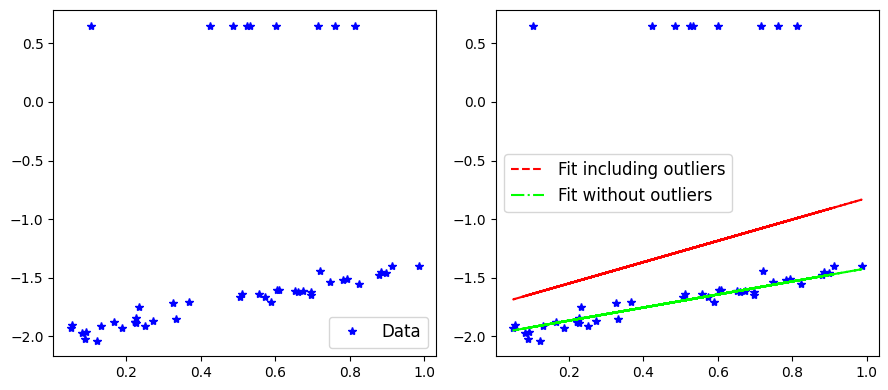

In [ ]:
num_samples = 50
x = np.random.uniform(size=num_samples)
print ('input data shape: ', x.shape)
check_slope = 0.6
intercept = -2

y = (x * check_slope) + intercept + np.random.normal(scale=0.05, size=num_samples)
print ('y shape: ', y.shape)

flip_mask = np.random.uniform(size=num_samples) > 0.8
y = np.where(flip_mask, 0.05 + 0.3 * (1. - np.sign(y - 0.2)), y)
y_no_outlier = (x * check_slope) + intercept + np.random.normal(scale=0.05, size=num_samples)

x_reshaped = x.reshape(-1, 1)
y_reshaped = y.reshape(-1, 1)
y_n_outlier_reshaped = y_no_outlier.reshape(-1, 1)

reg_outlier = LinearRegression().fit(x_reshaped, y_reshaped)
reg = LinearRegression().fit(x_reshaped, y_n_outlier_reshaped)

print ('fit coeff and intercept: ', reg.coef_, reg.intercept_)
print ('fit coeff and intercept without outlier: ', reg1.coef_, reg1.intercept_)

fitted_y = x * reg_outlier.coef_[0][0] + reg_outlier.intercept_[0]
fitted_y_n_outlier = x * reg.coef_[0][0] + reg.intercept_[0]

fig = plt.figure(figsize=(9, 4))
fig.add_subplot(121)
plt.plot(x, y, linestyle='None', marker='*', color='blue', label='Data')
plt.legend(fontsize=12)
fig.add_subplot(122)
plt.plot(x, y, linestyle='None', marker='*', color='blue', )

plt.plot(x, fitted_y, linestyle='--', color='red', label='Fit including outliers')
plt.plot(x, fitted_y_n_outlier, linestyle='-.', color='lime', label='Fit without outliers')
plt.legend(fontsize=12)
plt.tight_layout()
# plt.savefig('/content/gdrive/My Drive/Colab Notebooks/outlier.png', dpi=170)
plt.show()

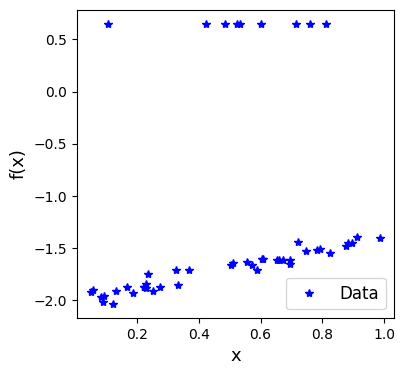

In [ ]:
fig = plt.figure(figsize=(9, 4))
fig.add_subplot(121)
plt.plot(x, y, linestyle='None', marker='*', color='blue', label='Data')
plt.legend(fontsize=12)
plt.xlabel('x', fontsize=13)
plt.ylabel(r'f(x)', fontsize=13)
plt.show()

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


SGD MAE coeff and intercept: [0.52348022] [-1.93193369]


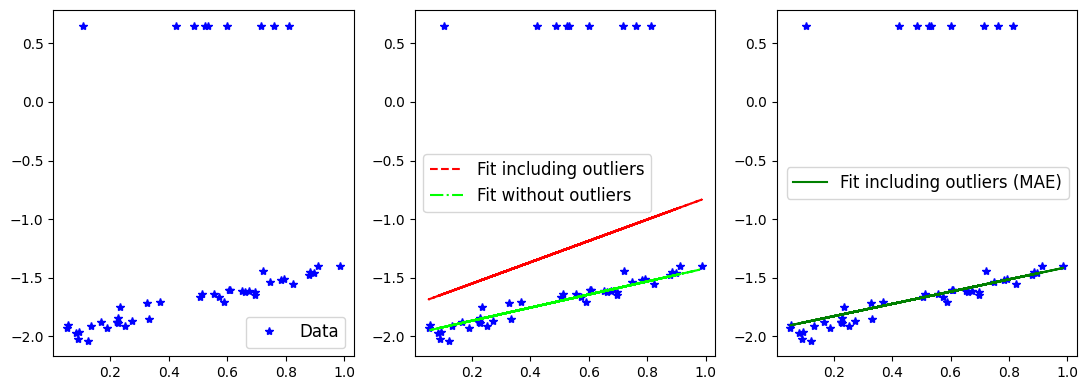

In [ ]:
from sklearn.linear_model import SGDRegressor

reg_mae_sgd = SGDRegressor(
    loss="huber",
    penalty=None,
    max_iter=5000,
    tol=1e-6,
    random_state=0
)

reg_mae_sgd.fit(x_reshaped, y_reshaped)

print("SGD MAE coeff and intercept:",
      reg_mae_sgd.coef_, reg_mae_sgd.intercept_)


fitted_y_mae = reg_mae_sgd.predict(x_reshaped)



fig = plt.figure(figsize=(11, 4))
fig.add_subplot(131)
plt.plot(x, y, linestyle='None', marker='*', color='blue', label='Data')
plt.legend(fontsize=12)

fig.add_subplot(132)
plt.plot(x, y, linestyle='None', marker='*', color='blue', )

plt.plot(x, fitted_y, linestyle='--', color='red', label='Fit including outliers')
plt.plot(x, fitted_y_n_outlier, linestyle='-.', color='lime', label='Fit without outliers')
plt.legend(fontsize=12)

fig.add_subplot(133)
plt.plot(x, y, linestyle='None', marker='*', color='blue', )

plt.plot(x, fitted_y_mae, linestyle='-', color='green', label='Fit including outliers (MAE)')
plt.legend(fontsize=12)
plt.tight_layout()
# plt.savefig('/content/gdrive/My Drive/Colab Notebooks/outlier.png', dpi=170)
plt.show()